In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
# DANE 2023

In [6]:
print("Wczytywanie danych")
df_dl_2023 = pd.read_csv(r'data-raw-2023-feb\202302\curr_httpgetmt.csv')
df_ul_2023 = pd.read_csv(r'data-raw-2023-feb\202302\curr_httppostmt.csv')

Wczytywanie danych


In [7]:
# Wyświetlenie początkowych wierszy
print(df_dl_2023.head())
print(df_ul_2023.head())

   unit_id                dtime                          target       address  \
0      386  2023-02-02 11:46:44  sp1-vm-newyork-us.samknows.com  151.139.31.1   
1      386  2023-02-02 17:46:29  sp1-vm-newyork-us.samknows.com  151.139.31.1   
2      386  2023-02-04 01:51:30  sp1-vm-newyork-us.samknows.com  151.139.31.1   
3      386  2023-02-05 17:47:10  sp2-vm-newyork-us.samknows.com  151.139.31.8   
4      386  2023-02-06 17:49:28  sp1-vm-newyork-us.samknows.com  151.139.31.1   

   fetch_time  bytes_total  bytes_sec  bytes_sec_interval  warmup_time  \
0    10028665    257012514   25627789            25627789      5028092   
1    10018544    255021762   25454972            25454972      1523612   
2    10046837    250815180   24964591            24964591      5016757   
3    10016105    258943152   25852679            25852679      5008756   
4    10028916    250831956   25010874            25010874      5019601   

   warmup_bytes  sequence  threads  successes  failures  
0     1220

In [8]:
# Selekcja kolumn
# unit_id - id użytkownika
# bytes_sec - średnia prędkość transferu
# dtime - data
cols_to_keep = ['unit_id', 'bytes_sec', 'dtime']
df_dl_2023 = df_dl_2023[cols_to_keep]
df_ul_2023 = df_ul_2023[cols_to_keep]

In [10]:
# Przeliczamy bajty/s na Megabity/s
# (bytes_sec * 8 / 1024 / 1024)
df_dl_2023['download_mbps'] = (df_dl_2023['bytes_sec'] * 8) / (1024 * 1024)
df_ul_2023['upload_mbps'] = (df_ul_2023['bytes_sec'] * 8) / (1024 * 1024)

In [11]:
# Agregacja danych
# Ponieważ każdy użytkownik (unit_id) wykonuje wiele testów, 
# wyciągamy średnią prędkość dla każdego z nich.
print("Agregowanie danych tych samych użytkowników")
df_dl_2023_avg = df_dl_2023.groupby('unit_id')['download_mbps'].mean().reset_index()
df_ul_2023_avg = df_ul_2023.groupby('unit_id')['upload_mbps'].mean().reset_index()

Agregowanie danych tych samych użytkowników


In [12]:
# Łączymy download i upload w jedną tabelę po unit_id
df_final_2023 = pd.merge(df_dl_2023_avg, df_ul_2023_avg, on='unit_id', how='inner')
print(f"Połączono dane dla {len(df_final_2023)} użytkowników.")
print(df_final_2023.head())

Połączono dane dla 4297 użytkowników.
   unit_id  download_mbps  upload_mbps
0      386     185.786548   150.929777
1      390      89.238678    89.492425
2      422     173.843533     5.622417
3      431      76.809517    89.556298
4      447      77.110546    84.489954


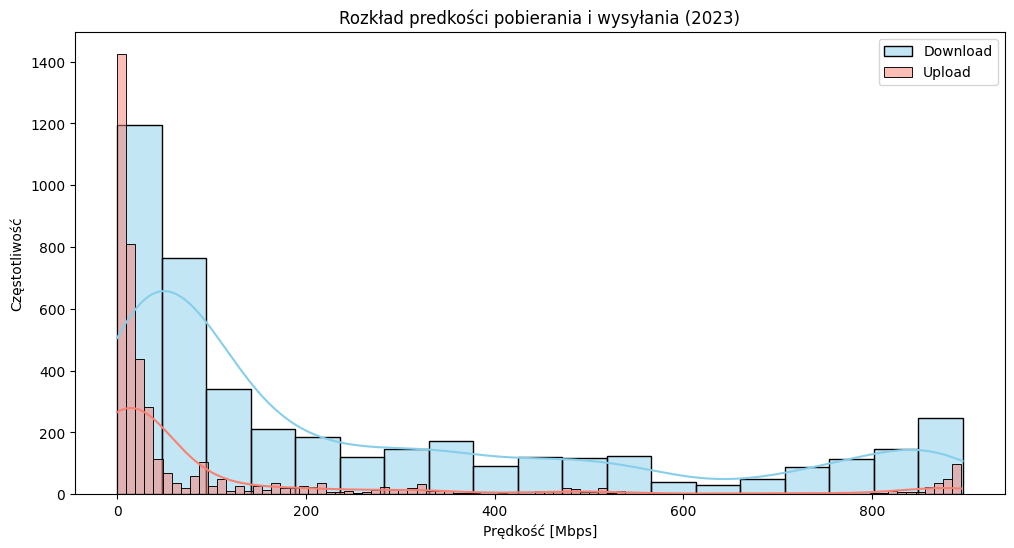

In [14]:
plt.figure(figsize=(12, 6))
sns.histplot(df_final_2023['download_mbps'], color="skyblue", label="Download", kde=True)
sns.histplot(df_final_2023['upload_mbps'], color="salmon", label="Upload", kde=True)
plt.title('Rozkład predkości pobierania i wysyłania (2023)')
plt.xlabel('Prędkość [Mbps]')
plt.ylabel('Częstotliwość')
plt.legend()
plt.savefig('Rozkład_download_upload.png')

In [17]:
# Konwersja dtime na obiekt daty i wyciągnięcie dnia tygodnia
df_dl_2023['dtime'] = pd.to_datetime(df_dl_2023['dtime'])
df_ul_2023['dtime'] = pd.to_datetime(df_ul_2023['dtime'])

df_dl_2023['day_of_week'] = df_dl_2023['dtime'].dt.day_name()
df_ul_2023['day_of_week'] = df_ul_2023['dtime'].dt.day_name()

# Agregacja średniej prędkości na użytkownika w konkretnym dniu
df_dl_day = df_dl_2023.groupby(['unit_id', 'day_of_week'])['download_mbps'].mean().reset_index()
df_ul_day = df_ul_2023.groupby(['unit_id', 'day_of_week'])['upload_mbps'].mean().reset_index()

# Łączymy w jedną tabelę
df_combined_day = pd.merge(df_dl_day, df_ul_day, on=['unit_id', 'day_of_week'], how='inner')

C:\Users\mikol\AppData\Local\Temp\ipykernel_27584\1013336746.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined_day, x='day_of_week', y='download_mbps',


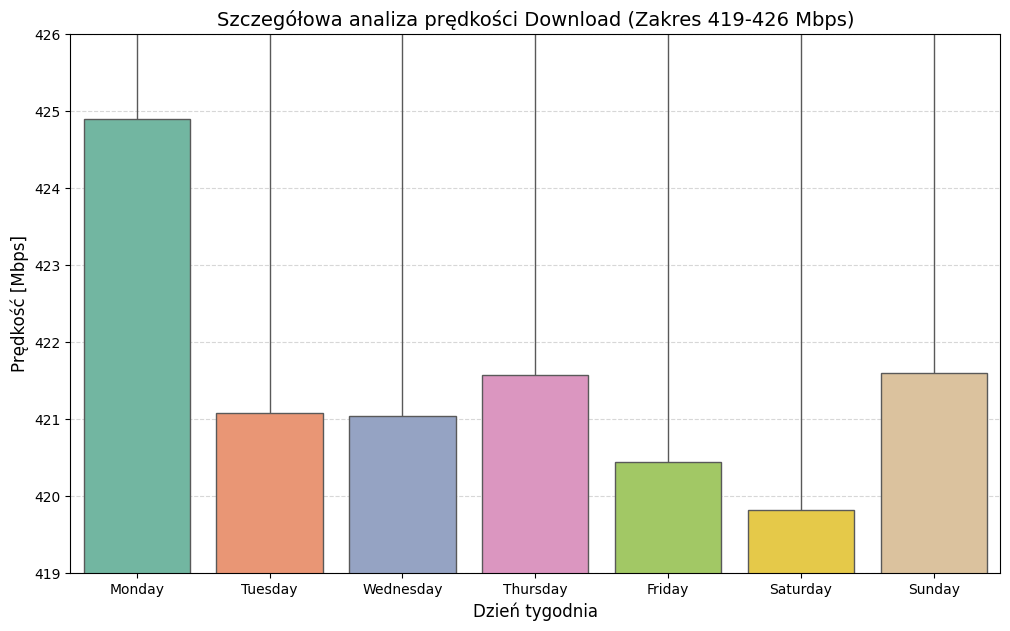

In [29]:
# Ustalenie kolejności dni
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(12, 7))

# Rysujemy wykres (boxplot lub pointplot - pointplot lepiej pokaże samą średnią)
sns.boxplot(data=df_combined_day, x='day_of_week', y='download_mbps', 
            order=days_order, palette='Set2', showfliers=False) # showfliers=False ukrywa kropki poza zakresem

# KLUCZOWY MOMENT: Ustawienie zakresu osi Y
plt.ylim(419, 426) 

# Dodajemy etykiety i siatkę
plt.title('Szczegółowa analiza prędkości Download (Zakres 419-426 Mbps)', fontsize=14)
plt.xlabel('Dzień tygodnia', fontsize=12)
plt.ylabel('Prędkość [Mbps]', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [24]:
# Upewnij się, że dtime jest w formacie datetime
df_dl_2023['dtime'] = pd.to_datetime(df_dl_2023['dtime'])

# Stwórz nową kolumnę z samą godziną
df_dl_2023['hour'] = df_dl_2023['dtime'].dt.hour

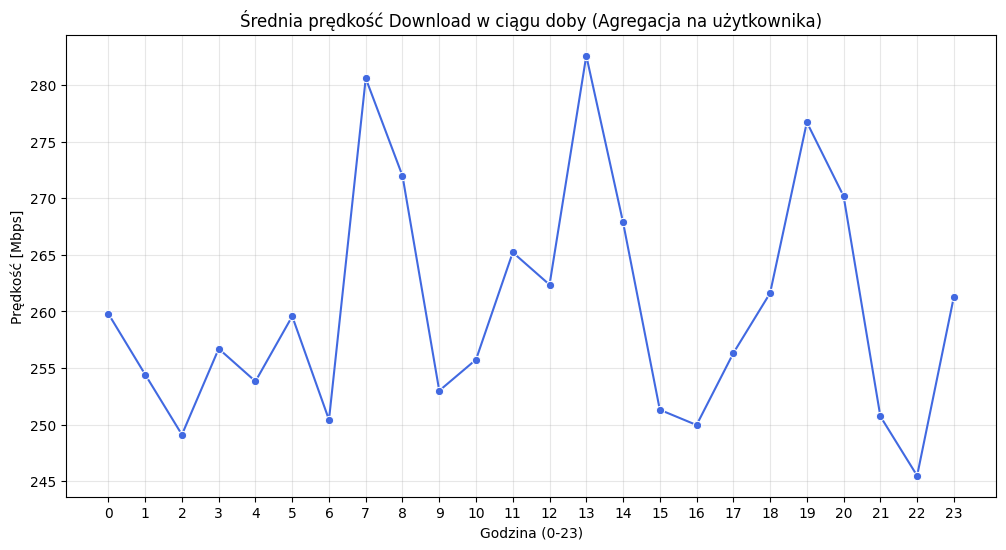

In [27]:
# KROK 1: Średnia dla każdego użytkownika w danej godzinie
df_hourly_user = df_dl_2023.groupby(['unit_id', 'hour'])['download_mbps'].mean().reset_index()

# KROK 2: Średnia ogólna z wyników użytkowników
hourly_avg = df_hourly_user.groupby('hour')['download_mbps'].mean().reset_index()

# Teraz rysujemy wykres - wartości będą w okolicach 400-420 Mbps
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_avg, x='hour', y='download_mbps', marker='o', color='royalblue')
plt.title('Średnia prędkość Download w ciągu doby (Agregacja na użytkownika)')
plt.xlabel('Godzina (0-23)')
plt.ylabel('Prędkość [Mbps]')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

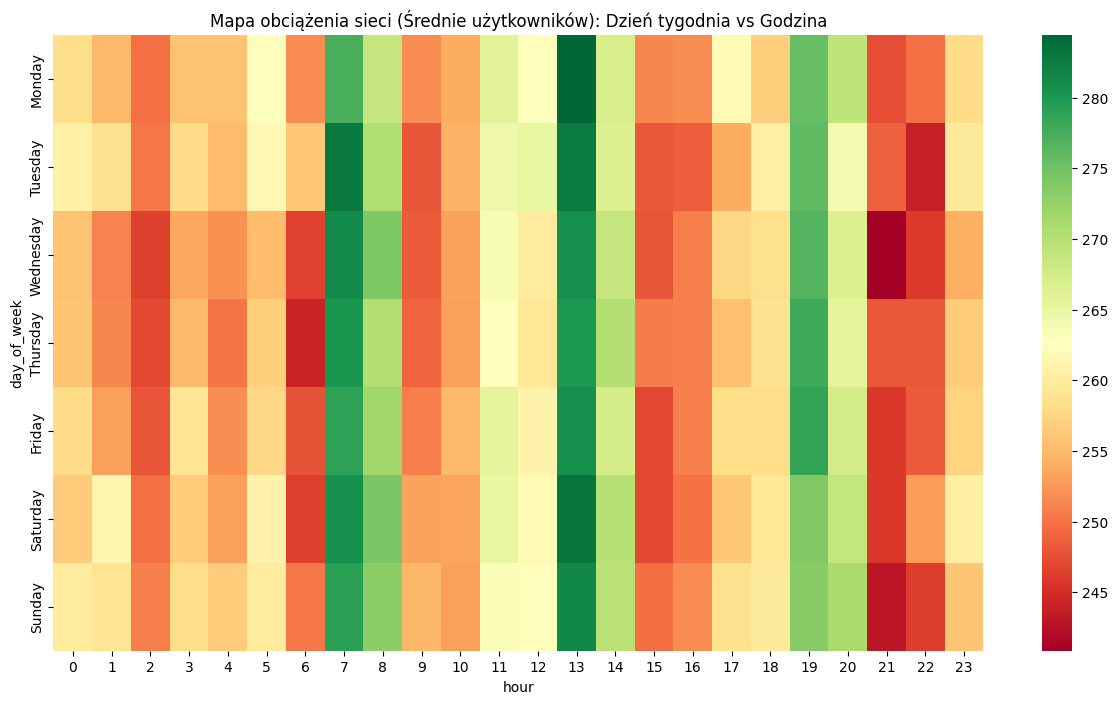

In [28]:
# Przygotowanie danych zagregowanych pod heatmapę
df_pivot_user = df_dl_2023.groupby(['unit_id', 'day_of_week', 'hour'])['download_mbps'].mean().reset_index()

pivot_table = df_pivot_user.pivot_table(values='download_mbps', 
                                     index='day_of_week', 
                                     columns='hour', 
                                     aggfunc='mean')

# Porządkujemy dni tygodnia
pivot_table = pivot_table.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize=(15, 8))
sns.heatmap(pivot_table, annot=False, cmap='RdYlGn')
plt.title('Mapa obciążenia sieci (Średnie użytkowników): Dzień tygodnia vs Godzina')
plt.show()

In [50]:
# DANE 2021

In [51]:
print("Wczytywanie danych")
df_dl_2021 = pd.read_csv(r'C:\Users\mikol\Desktop\PAMSI\Projekt1\data-raw-2021-feb\202102\curr_httpgetmt.csv')
df_ul_2021 = pd.read_csv(r'C:\Users\mikol\Desktop\PAMSI\Projekt1\data-raw-2021-feb\202102\curr_httppostmt.csv')

Wczytywanie danych


In [52]:
# Wyświetlenie początkowych wierszy
print(df_dl_2021.head())
print(df_ul_2021.head())

   unit_id                dtime                          target  \
0      386  2021-02-01 08:34:20  sp2-vm-newyork-us.samknows.com   
1      386  2021-02-01 14:35:59  sp2-vm-newyork-us.samknows.com   
2      386  2021-02-01 14:45:29     newyorkfcc.west.verizon.net   
3      390  2021-02-01 01:51:22  sp2-vm-newyork-us.samknows.com   
4      390  2021-02-01 03:51:19  sp2-vm-newyork-us.samknows.com   

          address  fetch_time  bytes_total  bytes_sec  bytes_sec_interval  \
0    151.139.31.8    10014585    220221348   21990062            21990062   
1    151.139.31.8    10013978    214999818   21469971            21469971   
2  206.124.86.197    10009155    198978368   19879637            19879637   
3    151.139.31.8    10033353    118023354   11763102            11763102   
4    151.139.31.8    10053968    116570832   11594510            11594510   

   warmup_time  warmup_bytes  sequence  threads  successes  failures  \
0      1509794      31294502         0        8          1    

In [53]:
# Selekcja kolumn
# unit_id - id użytkownika
# bytes_sec - średnia prędkość transferu
# dtime - data
cols_to_keep = ['unit_id', 'bytes_sec', 'dtime']
df_dl_2021 = df_dl_2021[cols_to_keep]
df_ul_2021 = df_ul_2021[cols_to_keep]

In [54]:
# Przeliczamy bajty/s na Megabity/s
# (bytes_sec * 8 / 1024 / 1024)
df_dl_2021['download_mbps'] = (df_dl_2021['bytes_sec'] * 8) / (1024 * 1024)
df_ul_2021['upload_mbps'] = (df_ul_2021['bytes_sec'] * 8) / (1024 * 1024)

In [55]:
# Agregacja danych
# Ponieważ każdy użytkownik (unit_id) wykonuje wiele testów, 
# wyciągamy średnią prędkość dla każdego z nich.
print("Agregowanie danych tych samych użytkowników")
df_dl_2021_avg = df_dl_2021.groupby('unit_id')['download_mbps'].mean().reset_index()
df_ul_2021_avg = df_ul_2021.groupby('unit_id')['upload_mbps'].mean().reset_index()

Agregowanie danych tych samych użytkowników


In [56]:
# Łączymy download i upload w jedną tabelę po unit_id
df_final_2021 = pd.merge(df_dl_2021_avg, df_ul_2021_avg, on='unit_id', how='inner')
print(f"Połączono dane dla {len(df_final_2021)} użytkowników.")
print(df_final_2021.head())

Połączono dane dla 5287 użytkowników.
   unit_id  download_mbps  upload_mbps
0        8      71.831611    88.405573
1      386     164.336290   139.052591
2      390      88.262947    88.739761
3      422     113.063085     5.651303
4      431      70.880217    87.076465
